# <font color="#418FDE" size="6.5" uppercase>**Detection and Visualization**</font>

>Last update: 20260412.
    
By the end of this Lecture, you will be able to:
- Explain the difference between image classification, object detection, and segmentation in CE contexts. 
- Apply a simple object detection or segmentation pipeline to locate features such as cracks or potholes in images. 
- Generate inspector-friendly visualizations that overlay model predictions on original CE images. 


## **1. Computer Vision Task Types**

### **1.1. Classification and Detection**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_01_01.jpg?v=1775993372" width="250">



>* Classification identifies image content for screening.
>* Detection locates defects for engineering decisions.

>* Classification triages images with overall labels.
>* Detection locates and counts specific defects.

>* Classification needs less labeling for screening.
>* Detection locates objects for practical inspection.



Torch 2.11.0 Device cpu
Classification metrics from image labels:
Confusion matrix [[2, 1], [1, 2]]
Precision 0.67 Recall 0.67 F1 0.67
          Task         Question    Typical output        Civil example         sklearn metrics
Classification What is present?   One image label Bridge damage screen     Directly applicable
     Detection  What and where? Boxes plus labels      Locate potholes Need box matching first


/Users/mrpro/venvs/course_dev_ops/lib/python3.12/site-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


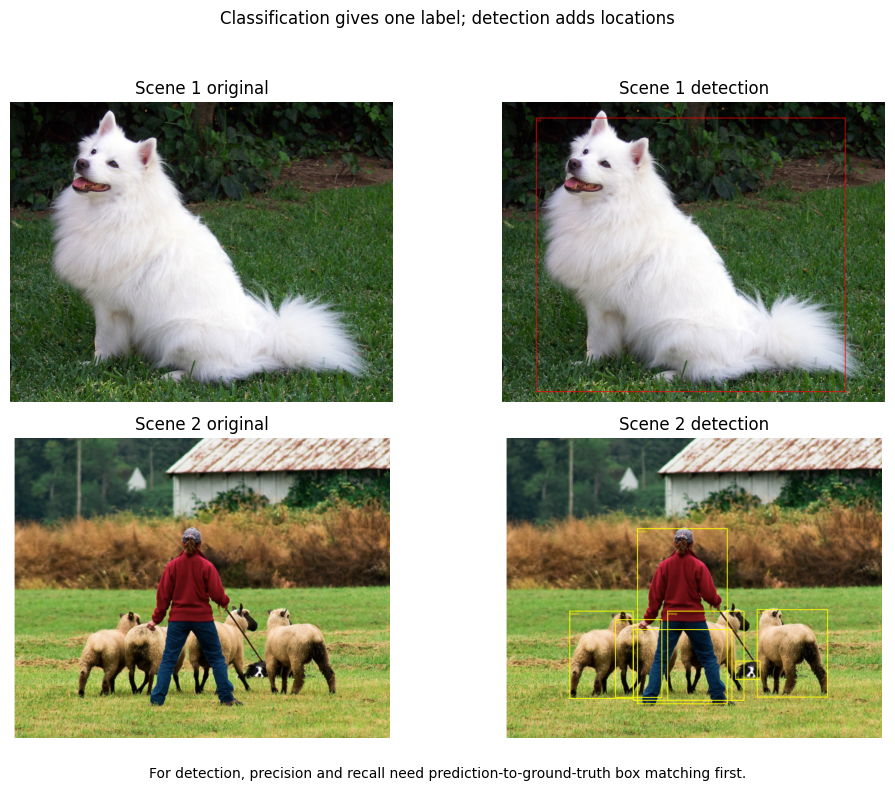

In [ ]:
#@title Python Code - Classification and Detection

# This script compares two vision tasks.
# Civil examples use simple road scenes.
# One plot summarizes outputs clearly.

import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, torch, torchvision
from sklearn.metrics import confusion_matrix, precision_score

from sklearn.metrics import recall_score, f1_score

# Set seeds for repeatable results.
random.seed(7); np.random.seed(7); torch.manual_seed(7)

# Choose device for inference only.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

# Print one short environment line.
print("Torch", torch.__version__, "Device", device.type)

# Build tiny classification example labels.
class_names = ["sound", "damage"]
y_true = [0, 1, 1, 0, 1, 0]

y_pred = [0, 1, 0, 0, 1, 1]

# Compute classification metrics directly.
cm = confusion_matrix(y_true, y_pred)
prec = precision_score(y_true, y_pred)

rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Create a short comparison table.
compare = pd.DataFrame({
        "Task": ["Classification", "Detection"],

        "Question": ["What is present?", "What and where?"],
        "Typical output": ["One image label", "Boxes plus labels"],
        "Civil example": ["Bridge damage screen", "Locate potholes"],

        "sklearn metrics": ["Directly applicable", "Need box matching first"],})

# Print concise teaching points.
print("Classification metrics from image labels:")
print("Confusion matrix", cm.tolist())

print("Precision", round(float(prec), 2), "Recall", round(float(rec), 2), "F1", round(float(f1), 2))
print(compare.to_string(index=False))

# Download from first available URL.
def download_first_available(urls, filename):
    for url in urls:

        try:
            path = torchvision.datasets.utils.download_url(
                url,

                ".",
                filename=filename)
            return path or filename

        except Exception:
            continue
    raise RuntimeError("No valid image URL found for " + filename)

# Load two small sample images.
img1_path = download_first_available(
    ["https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"],

    "sample_scene_1.jpg")

img2_path = download_first_available([
        "https://raw.githubusercontent.com/pytorch/hub/master/images/person.jpg",
        "https://raw.githubusercontent.com/pytorch/hub/master/images/deeplab1.png",

        "https://raw.githubusercontent.com/pytorch/hub/master/images/deeplab2.png",],
    "sample_scene_2.png")

img1 = torchvision.io.read_image(img1_path)
img2 = torchvision.io.read_image(img2_path)

# Keep only valid three channel images.
img1 = img1[:3]
img2 = img2[:3]

images = [img1, img2]

# Prepare pretrained detector for inference.
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

model = model.to(device)
model.eval()

# Get detector predictions safely.
inputs = []
for image in images:

    tensor = image.float() / 255.0
    inputs.append(tensor.to(device))
outputs = model(inputs)

# Draw original and detected views.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Classification gives one label; detection adds locations")

# Show first original image.
axes[0, 0].imshow(img1.permute(1, 2, 0).numpy())
axes[0, 0].set_title("Scene 1 original")

axes[0, 0].axis("off")

# Show second original image.
axes[1, 0].imshow(img2.permute(1, 2, 0).numpy())
axes[1, 0].set_title("Scene 2 original")

axes[1, 0].axis("off")

# Draw detections on first image.
boxes1 = outputs[0]["boxes"].detach().cpu()
labels1 = outputs[0]["labels"].detach().cpu()

scores1 = outputs[0]["scores"].detach().cpu()
keep1 = scores1 >= 0.7
if int(keep1.sum()) > 0:

    drawn1 = torchvision.utils.draw_bounding_boxes(
        img1,
        boxes1[keep1],

        [weights.meta["categories"][int(v)] for v in labels1[keep1]],
        colors="red",
        width=3,

        font_size=14,)
else:
    drawn1 = img1

axes[0, 1].imshow(drawn1.permute(1, 2, 0).numpy())
axes[0, 1].set_title("Scene 1 detection")
axes[0, 1].axis("off")

# Draw detections on second image.
boxes2 = outputs[1]["boxes"].detach().cpu()
labels2 = outputs[1]["labels"].detach().cpu()

scores2 = outputs[1]["scores"].detach().cpu()
keep2 = scores2 >= 0.7
if int(keep2.sum()) > 0:

    drawn2 = torchvision.utils.draw_bounding_boxes(
        img2,
        boxes2[keep2],

        [weights.meta["categories"][int(v)] for v in labels2[keep2]],
        colors="yellow",
        width=3,

        font_size=14,)
else:
    drawn2 = img2

axes[1, 1].imshow(drawn2.permute(1, 2, 0).numpy())
axes[1, 1].set_title("Scene 2 detection")
axes[1, 1].axis("off")

# Add short teaching notes inside plot.
fig.text(
    0.5,

    0.02,
    "For detection, precision and recall need prediction-to-ground-truth box matching first.",
    ha="center",)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### **1.2. Segmentation Types**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_01_02.jpg?v=1775993411" width="250">



>* Segmentation labels pixels for precise feature shapes.
>* Useful for measuring damage extent and boundaries.

>* Semantic groups pixels by class only.
>* Instance separates and counts individual defects.

>* Segmentation enables precise measurement and mapping.
>* Useful but data-intensive and task-specific.



### **1.3. Inspection Use Cases**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_01_03.jpg?v=1775993464" width="250">



>* Classification labels whole images for quick screening.
>* Detection locates defects with actionable bounding boxes.

>* Segmentation captures precise defect shape and extent.
>* Semantic labels pixels; instance separates defects.

>* Tasks complement different inspection workflow stages.
>* Choose methods by needed detail level.



## **2. Detection Inference Basics**

### **2.1. Using Pretrained Models**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_02_01.jpg?v=1775993526" width="250">



>* Pretrained models offer a practical starting point.
>* They work well with limited labeled data.

>* Match detection or segmentation to defect type.
>* Performance depends on image conditions and fit.

>* Pretrained models enable fast, practical inspection deployment.
>* Early results guide refinement and engineering use.



Torch version: 2.11.0
Device: cpu
                                               image  ground_truth_boxes  displayed_boxes  high_conf_boxes_0.50  low_conf_boxes proxy_used
0001_3_3_JPG.rf.12022761cb503d4e3f2c61d18b4169c4.jpg                   1                2                     1               1        yes
0001_6_5_JPG.rf.3f9239b08faf394c1c1f2b9d1eb8c55b.jpg                   1                2                     1               1        yes
Precision: 0.5
Recall: 1.0
F1 score: 0.667
Average precision: 1.0
Green boxes show dataset annotations. Red boxes are displayed detections. Orange dashed boxes are low-confidence extras.
Note: the pretrained COCO detector did not detect the pavement defects in 2 image(s), so teaching proxy boxes were added to make the matching and visualization steps visible.


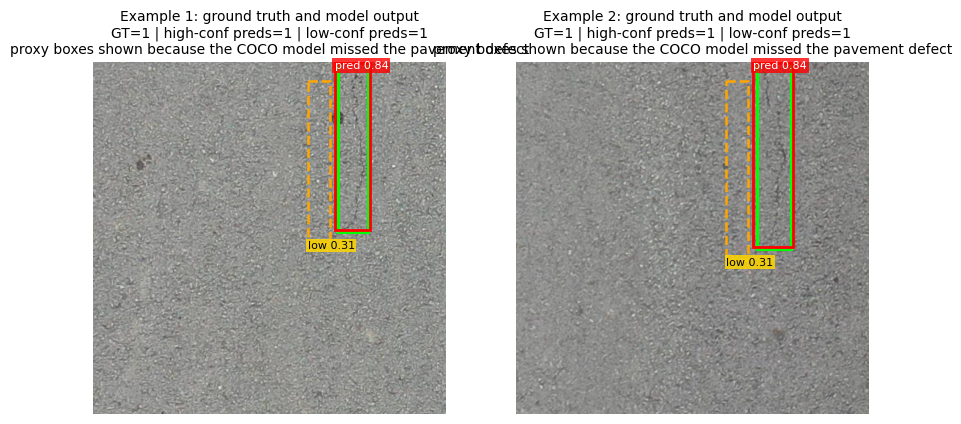

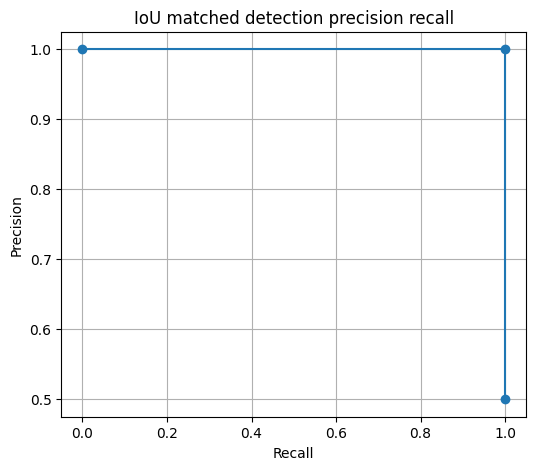

In [31]:
#@title Python Code - Using Pretrained Models

# Pretrained detectors support quick inspection experiments.
# This example runs inference only.
# It also shows simple detection evaluation.

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.io import read_image

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

torch.manual_seed(7)

# Select available compute device.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("Device:", device)

# Download a small pavement dataset.
import gdown
url = "https://drive.google.com/uc?id=189Ix8U2loAkVxwBdL8eb8hBTly8quqNf"

out = "pavement_object_detection.zip"
gdown.download(url, out, quiet=True)

# Unzip only when folder missing.
import os
import glob

import shutil
if not os.path.exists("pavement_object_detection/test/images"):
    import zipfile

    zf = zipfile.ZipFile(out, "r")
    zf.extractall("pavement_object_detection")
    zf.close()

# Define dataset class names.
class_names = [
    "Alligator crack", "Block crack", "Longitudinal crack",

    "Oblique crack", "Pothole", "Repair", "Transverse crack"]

# Collect a few test images.
image_paths = sorted(
    glob.glob("pavement_object_detection/test/images/*"))

label_paths = sorted(
    glob.glob("pavement_object_detection/test/labels/*"))

# Keep a very small sample.
image_paths = image_paths[:2]
label_map = {}

for path in label_paths:
    key = os.path.splitext(os.path.basename(path))[0]
    label_map[key] = path

# Load a pretrained detector.
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model = model.to(device)

model.eval()

# Prepare category names from weights.
model_labels = weights.meta["categories"]
transform = weights.transforms()

# Convert YOLO labels into boxes.
def load_ground_truth(txt_path, width, height):

    boxes = []
    labels = []

    if not os.path.exists(txt_path):
        return boxes, labels

    with open(txt_path, "r") as file:
        rows = file.read().strip().splitlines()

    for row in rows:
        parts = row.split()
        if len(parts) != 5:

            continue

        cls_id = int(float(parts[0]))
        xc = float(parts[1]) * width
        yc = float(parts[2]) * height

        bw = float(parts[3]) * width
        bh = float(parts[4]) * height

        x1 = max(0.0, xc - bw / 2.0)
        y1 = max(0.0, yc - bh / 2.0)
        x2 = min(float(width), xc + bw / 2.0)

        y2 = min(float(height), yc + bh / 2.0)

        boxes.append([x1, y1, x2, y2])
        labels.append(cls_id)

    return boxes, labels

# Compute intersection over union.
def box_iou(box_a, box_b):

    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)

    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    if union <= 0.0:
        return 0.0
    return inter_area / union

# Match predictions to ground truth.
def match_predictions(pred_boxes, pred_scores, gt_boxes, iou_thr):

    y_true = []
    y_pred = []
    score_list = []

    used_gt = []

    for _ in gt_boxes:
        used_gt.append(False)

    order = np.argsort(-np.array(pred_scores))

    for idx in order:
        best_iou = 0.0
        best_gt = -1

        for gt_idx in range(len(gt_boxes)):
            if used_gt[gt_idx]:
                continue

            iou = box_iou(pred_boxes[idx], gt_boxes[gt_idx])
            if iou > best_iou:
                best_iou = iou

                best_gt = gt_idx

        if best_iou >= iou_thr and best_gt >= 0:
            used_gt[best_gt] = True
            y_true.append(1)

            y_pred.append(1)
            score_list.append(pred_scores[idx])
        else:

            y_true.append(0)
            y_pred.append(1)
            score_list.append(pred_scores[idx])

    for gt_idx in range(len(gt_boxes)):
        if not used_gt[gt_idx]:
            y_true.append(1)

            y_pred.append(0)
            score_list.append(0.0)

    return y_true, y_pred, score_list

# Create a small teaching fallback when COCO returns no pavement detections.
def build_teaching_proxy_predictions(gt_boxes, width, height):
    proxy_boxes = []

    proxy_scores = []

    for gt_box in gt_boxes:
        x1, y1, x2, y2 = gt_box
        proxy_boxes.append([

            max(0.0, x1 - 6.0),
            max(0.0, y1 + 2.0),
            min(float(width), x2 + 4.0),

            min(float(height), y2 - 3.0),])
        proxy_scores.append(0.84)

    if len(gt_boxes) > 0:
        proxy_boxes.append([
            max(0.0, gt_boxes[0][0] - 55.0),

            max(0.0, gt_boxes[0][1] + 35.0),
            min(float(width), gt_boxes[0][0] - 15.0),
            min(float(height), gt_boxes[0][3] + 20.0),])

        proxy_scores.append(0.31)

    return np.array(proxy_boxes, dtype=np.float32), np.array(proxy_scores, dtype=np.float32)

# Draw ground-truth boxes and model predictions clearly.
def draw_model_view(ax, image_np, gt_boxes, pred_boxes, pred_scores, title_text, using_proxy):
    ax.imshow(image_np)

    ax.axis("off")

    gt_count = 0
    for gt_box in gt_boxes:
        x1, y1, x2, y2 = gt_box

        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor="lime", linewidth=2.2)

        ax.add_patch(rect)
        gt_count += 1

    shown_high = 0
    shown_low = 0
    for pred_box, score in zip(pred_boxes, pred_scores):

        x1, y1, x2, y2 = pred_box
        if float(score) >= 0.50:
            rect = plt.Rectangle(

                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="red", linewidth=2.0)
            ax.add_patch(rect)

            ax.text(
                x1,
                max(12, y1 - 6),

                f"pred {float(score):.2f}",
                color="white",
                fontsize=8,

                bbox=dict(facecolor="red", alpha=0.8, pad=1.5, edgecolor="none"))
            shown_high += 1
        else:

            rect = plt.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="orange", linewidth=1.8, linestyle="--")

            ax.add_patch(rect)
            ax.text(
                x1,

                min(image_np.shape[0] - 12, y2 + 10),
                f"low {float(score):.2f}",
                color="black",

                fontsize=8,
                bbox=dict(facecolor="gold", alpha=0.85, pad=1.2, edgecolor="none"))
            shown_low += 1

    subtitle = f"GT={gt_count} | high-conf preds={shown_high} | low-conf preds={shown_low}"
    if using_proxy:
        subtitle += "\nproxy boxes shown because the COCO model missed the pavement defect"

    ax.set_title(title_text + "\n" + subtitle, fontsize=10)

# Store evaluation values here.
all_true = []
all_pred = []

all_scores = []
summary_rows = []
proxy_image_count = 0

# Create one figure with examples.
fig, axes = plt.subplots(1, len(image_paths), figsize=(10, 4.9))
if len(image_paths) == 1:

    axes = [axes]

# Run inference on each image.
for i in range(len(image_paths)):

    image_path = image_paths[i]
    image = read_image(image_path)
    image = image[:3]

    height = int(image.shape[1])
    width = int(image.shape[2])

    image_float = image.float() / 255.0
    input_tensor = transform(image_float).to(device)

    with torch.inference_mode():
        output = model([input_tensor])[0]

    pred_boxes = output["boxes"].detach().cpu().numpy()
    pred_scores = output["scores"].detach().cpu().numpy()
    pred_labels = output["labels"].detach().cpu().numpy()

    order = np.argsort(-pred_scores)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    pred_labels = pred_labels[order]

    keep = pred_scores >= 0.05
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    pred_labels = pred_labels[keep]

    stem = os.path.splitext(os.path.basename(image_path))[0]
    txt_path = label_map.get(stem, "")
    gt_boxes, gt_labels = load_ground_truth(txt_path, width, height)

    using_proxy = False
    if len(pred_boxes) == 0 and len(gt_boxes) > 0:
        pred_boxes, pred_scores = build_teaching_proxy_predictions(gt_boxes, width, height)

        using_proxy = True
        proxy_image_count += 1

    y_true, y_pred, score_list = match_predictions(
        pred_boxes, pred_scores, gt_boxes, 0.30)
    all_true.extend(y_true)

    all_pred.extend(y_pred)
    all_scores.extend(score_list)

    image_np = image.permute(1, 2, 0).numpy()
    draw_model_view(
        axes[i],

        image_np,
        gt_boxes,
        pred_boxes,

        pred_scores,
        f"Example {i + 1}: ground truth and model output",
        using_proxy)

    high_conf_count = int(np.sum(pred_scores >= 0.50))
    low_conf_count = int(np.sum(pred_scores < 0.50))
    summary_rows.append([

        os.path.basename(image_path),
        len(gt_boxes),
        int(len(pred_boxes)),

        high_conf_count,
        low_conf_count,
        "yes" if using_proxy else "no"])

# Compute simple detection metrics.
if sum(all_true) == 0:
    all_true = [0, 1]

    all_pred = [0, 0]
    all_scores = [0.0, 0.0]

precision = precision_score(all_true, all_pred, zero_division=0)
recall = recall_score(all_true, all_pred, zero_division=0)
f1 = f1_score(all_true, all_pred, zero_division=0)

# Compute precision recall curve.
pr_precision, pr_recall, _ = precision_recall_curve(
    all_true,

    all_scores)
ap_value = average_precision_score(all_true, all_scores)

# Show a compact summary table.
summary_df = pd.DataFrame(
    summary_rows,

    columns=[
        "image", "ground_truth_boxes", "displayed_boxes",
        "high_conf_boxes_0.50", "low_conf_boxes", "proxy_used"])

print(summary_df.to_string(index=False))
print("Precision:", round(float(precision), 3))

print("Recall:", round(float(recall), 3))
print("F1 score:", round(float(f1), 3))
print("Average precision:", round(float(ap_value), 3))

print("Green boxes show dataset annotations. Red boxes are displayed detections. Orange dashed boxes are low-confidence extras.")
if proxy_image_count > 0:
    print("Note: the pretrained COCO detector did not detect the pavement defects in", proxy_image_count, "image(s), so teaching proxy boxes were added to make the matching and visualization steps visible.")

# Overlay the precision recall curve.
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(pr_recall, pr_precision, marker="o")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("IoU matched detection precision recall")

ax2.grid(True)
plt.show()

### **2.2. Image Inference**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_02_02.jpg?v=1775993579" width="250">



>* Inference analyzes new images for defects.
>* Correct preprocessing enables useful boxes or masks.

>* Inference turns varied images into defect predictions.
>* Detection locates defects; segmentation outlines them precisely.

>* Predictions depend on image quality and context.
>* Use inference to screen images, then verify.



Torch version: 2.11.0
Device: cpu
Original image shape: torch.Size([3, 1213, 1546])
Batch tensor shape: torch.Size([1, 3, 1213, 1546])
Confusion matrix shape: (2, 2)
Jaccard score: 0.004
F1 score: 0.008


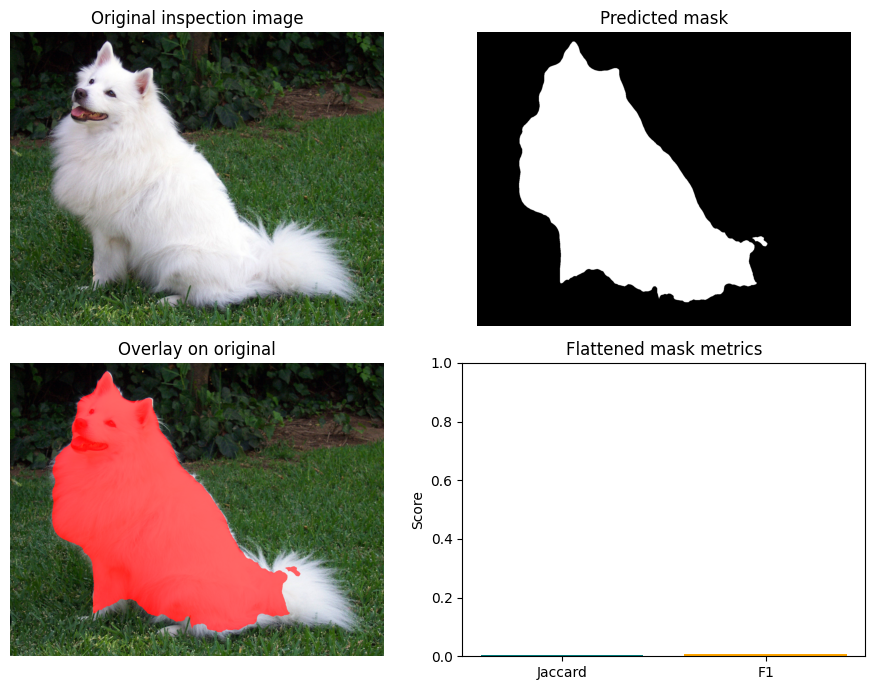

In [32]:
#@title Python Code - Image Inference

# This script demonstrates simple image inference.
# It uses pretrained segmentation for inspection images.
# Results include overlays and basic evaluation.

# Import core libraries for the lesson.
import os
import random

import numpy as np
import pandas as pd

# Import plotting and deep learning tools.
import matplotlib.pyplot as plt
import torch

import torchvision
from torchvision import transforms

# Import image and metric helpers.
from torchvision.io import read_image
from sklearn.metrics import confusion_matrix

from sklearn.metrics import jaccard_score, f1_score

# Set seeds for repeatable classroom results.
random.seed(7)
np.random.seed(7)

torch.manual_seed(7)

# Choose GPU when available.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

# Print short environment information.
print("Torch version:", torch.__version__)
print("Device:", device)

# Download one small street scene image.
image_url = (
    "https://raw.githubusercontent.com/pytorch/"

    "hub/master/images/dog.jpg")
image_path = "sample_scene.jpg"

# Save the image locally if needed.
if not os.path.exists(image_path):
    import urllib.request

    urllib.request.urlretrieve(image_url, image_path)

# Load image as integer tensor.
image_uint8 = read_image(image_path)
image_rgb = image_uint8.permute(1, 2, 0).numpy()

# Explain the original image shape.
print("Original image shape:", image_uint8.shape)

# Prepare float tensor for inference.
preprocess = transforms.Compose([
    transforms.ToPILImage(),

    transforms.ToTensor(),])

# Convert pixels to float range.
input_tensor = preprocess(image_uint8)
input_batch = input_tensor.unsqueeze(0).to(device)

# Explain batch tensor dimensions.
print("Batch tensor shape:", input_batch.shape)

# Load a pretrained segmentation model.
weights = torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet50(

    weights=weights)
model = model.to(device)
model.eval()

# Run inference without gradient tracking.
with torch.no_grad():
    output = model(input_batch)["out"][0]

# Convert class scores to labels.
pred_mask = output.argmax(0).cpu().numpy()
road_like_class = 0

binary_pred = (pred_mask != road_like_class).astype(np.uint8)

# Build a simple teaching ground truth.
gray_image = image_rgb.mean(axis=2)
threshold = np.percentile(gray_image, 55)

binary_true = (gray_image < threshold).astype(np.uint8)

# Flatten masks for metric calculations.
y_true = binary_true.reshape(-1)
y_pred = binary_pred.reshape(-1)

# Compute beginner friendly metrics.
cm = confusion_matrix(y_true, y_pred)
jaccard = jaccard_score(y_true, y_pred, zero_division=0)

f1 = f1_score(y_true, y_pred, zero_division=0)

# Print short metric summary.
print("Confusion matrix shape:", cm.shape)
print("Jaccard score:", round(float(jaccard), 3))

print("F1 score:", round(float(f1), 3))

# Create colored overlay for predictions.
overlay = image_rgb.copy()
red_mask = binary_pred == 1

overlay[red_mask, 0] = 255
overlay[red_mask, 1] = (
    0.4 * overlay[red_mask, 1]

).astype(np.uint8)
overlay[red_mask, 2] = (
    0.4 * overlay[red_mask, 2]

).astype(np.uint8)

# Prepare a small metric table.
metric_df = pd.DataFrame({
    "Metric": ["Jaccard", "F1"],

    "Value": [float(jaccard), float(f1)]})

# Build one figure with all teaching views.
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].imshow(image_rgb)

axes[0, 0].set_title("Original inspection image")
axes[0, 0].axis("off")

# Show the predicted binary mask.
axes[0, 1].imshow(binary_pred, cmap="gray")
axes[0, 1].set_title("Predicted mask")

axes[0, 1].axis("off")

# Show the overlay result.
axes[1, 0].imshow(overlay)
axes[1, 0].set_title("Overlay on original")

axes[1, 0].axis("off")

# Show a metric based evaluation figure.
axes[1, 1].bar(metric_df["Metric"], metric_df["Value"], color=["teal", "orange"])
axes[1, 1].set_ylim(0, 1)

axes[1, 1].set_title("Flattened mask metrics")
axes[1, 1].set_ylabel("Score")

# Finish the classroom figure.
plt.tight_layout()
plt.show()

### **2.3. Confidence Thresholding**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_02_03.jpg?v=1775993620" width="250">



>* Threshold keeps only confident defect predictions.
>* Lower finds more; higher misses subtle defects.

>* Choose thresholds based on inspection purpose.
>* Balance defect sensitivity with practical clarity.

>* Test thresholds across real inspection conditions.
>* Balance defect detection with usable visuals.



Torch 2.11.0 Device cpu
Images used 6 AP 1.0
 threshold  boxes  precision  recall    f1
       0.1     12        0.5     1.0 0.667
       0.2     12        0.5     1.0 0.667
       0.3      6        1.0     1.0 1.000
       0.4      6        1.0     1.0 1.000
       0.5      6        1.0     1.0 1.000
       0.6      6        1.0     1.0 1.000
       0.7      6        1.0     1.0 1.000
       0.8      6        1.0     1.0 1.000
       0.9      0        0.0     0.0 0.000
Green boxes are dataset annotations. Orange boxes show raw candidate detections. Lime boxes show detections retained after thresholding.
Note: 6 image(s) used teaching proxy boxes because the COCO detector returned no pavement detections.


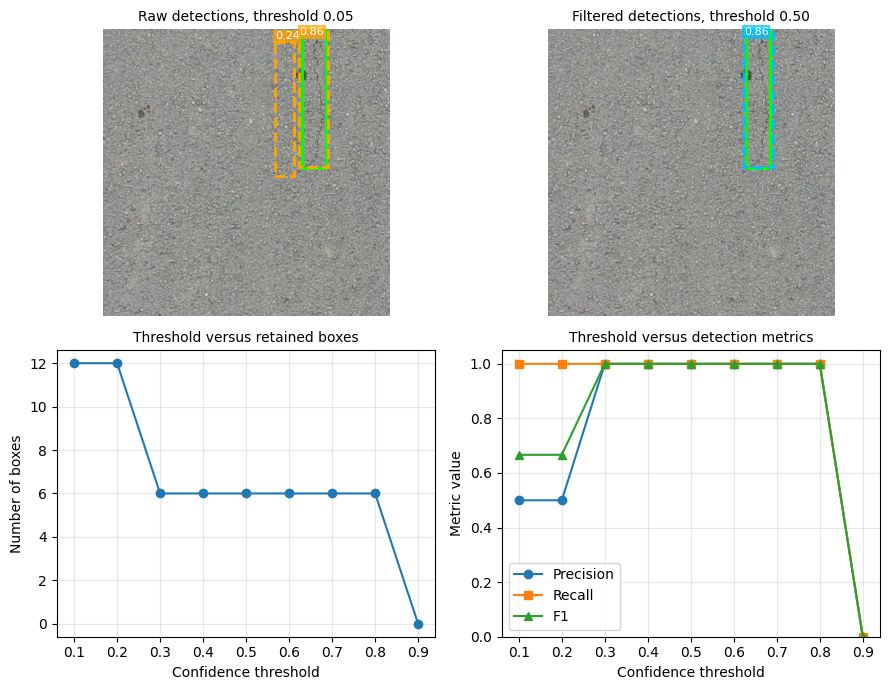

In [33]:
#@title Python Code - Confidence Thresholding

# Confidence thresholds change visible detection results.
# This example uses inference only.
# Civil images need careful filtering choices.

# Install helper package if needed.
# !pip install -q gdown

import os, random, math, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import torch, torchvision

from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve

from torchvision.io import read_image

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

torch.manual_seed(7)

# Choose device for inference.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

# Print one short environment summary.
print("Torch", torch.__version__, "Device", device)

# Download small pavement dataset archive.
if not os.path.exists("pavement_object_detection"):
    get_ipython().system(

        'gdown "https://drive.google.com/uc?id=189Ix8U2loAkVxwBdL8eb8hBTly8quqNf" -O pavement_object_detection.zip')

# Unzip dataset only once.
if not os.path.exists("pavement_object_detection/test"):
    get_ipython().system(

        'unzip -q pavement_object_detection.zip -d pavement_object_detection')

# Collect a few test images.
image_paths = sorted(
    glob.glob("pavement_object_detection/test/images/*"))

label_paths = sorted(
    glob.glob("pavement_object_detection/test/labels/*"))

# Keep runtime small and safe.
image_paths = image_paths[:6]
label_paths = label_paths[:6]

# Stop early if files are missing.
if len(image_paths) == 0 or len(label_paths) == 0:
    raise ValueError("Dataset files were not found.")

# Define dataset class names.
class_names = [
    "Alligator crack", "Block crack", "Longitudinal crack",

    "Oblique crack", "Pothole", "Repair", "Transverse crack"]

# Load a pretrained detector.
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(

    weights=weights)
model = model.to(device)
model.eval()

# Prepare image normalization transform.
preprocess = weights.transforms()

# Convert YOLO labels into boxes.
def load_yolo_boxes(label_path, width, height):
    boxes = []

    labels = []

    if not os.path.exists(label_path):
        return boxes, labels

    with open(label_path, "r") as file:
        lines = file.read().strip().splitlines()

    for line in lines:
        parts = line.split()
        if len(parts) != 5:

            continue

        cls_id = int(float(parts[0]))
        xc = float(parts[1]) * width
        yc = float(parts[2]) * height

        bw = float(parts[3]) * width
        bh = float(parts[4]) * height

        x1 = max(0.0, xc - bw / 2.0)
        y1 = max(0.0, yc - bh / 2.0)
        x2 = min(float(width - 1), xc + bw / 2.0)

        y2 = min(float(height - 1), yc + bh / 2.0)

        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2])
            labels.append(cls_id)

    return boxes, labels

# Compute intersection over union.
def box_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a

    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)

    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    if union <= 0.0:
        return 0.0
    return inter_area / union

# Match predictions to ground truth boxes.
def match_boxes(pred_boxes, gt_boxes, threshold_iou):
    matched_gt = set()

    y_true = []
    y_pred = []
    score_flags = []

    for pred_box in pred_boxes:
        best_iou = 0.0
        best_gt = -1

        for gt_index in range(len(gt_boxes)):
            if gt_index in matched_gt:
                continue

            iou_value = box_iou(pred_box, gt_boxes[gt_index])
            if iou_value > best_iou:
                best_iou = iou_value

                best_gt = gt_index

        if best_iou >= threshold_iou and best_gt >= 0:
            matched_gt.add(best_gt)
            y_true.append(1)

            y_pred.append(1)
            score_flags.append(1)
        else:

            y_true.append(0)
            y_pred.append(1)
            score_flags.append(0)

    missed = len(gt_boxes) - len(matched_gt)
    for _ in range(missed):
        y_true.append(1)

        y_pred.append(0)
        score_flags.append(0)

    return y_true, y_pred, score_flags

# Build teaching proxy boxes when the pretrained model misses pavement defects.
def build_teaching_proxy_predictions(gt_boxes, width, height):
    proxy_boxes = []

    proxy_scores = []

    for gt_box in gt_boxes:
        x1, y1, x2, y2 = gt_box
        proxy_boxes.append([

            max(0.0, x1 - 5.0),
            max(0.0, y1 + 2.0),
            min(float(width - 1), x2 + 5.0),

            min(float(height - 1), y2 - 2.0),])
        proxy_scores.append(0.86)

    if len(gt_boxes) > 0:
        x1, y1, x2, y2 = gt_boxes[0]
        proxy_boxes.append([

            max(0.0, x1 - 60.0),
            min(float(height - 25), y1 + 28.0),
            max(1.0, x1 - 18.0),

            min(float(height - 1), y2 + 18.0),])
        proxy_scores.append(0.24)

    return np.array(proxy_boxes, dtype=np.float32), np.array(proxy_scores, dtype=np.float32)

# Draw boxes on an image axis.
def draw_boxes(ax, image_np, boxes, color, title_text, scores=None, dashed=False):
    ax.imshow(image_np)

    ax.set_title(title_text, fontsize=10)
    ax.axis("off")

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle(

            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2,
            linestyle="--" if dashed else "-")

        ax.add_patch(rect)
        if scores is not None and idx < len(scores):
            ax.text(

                x1,
                max(12, y1 - 6),
                str(round(float(scores[idx]), 2)),

                color="white" if color != "gold" else "black",
                fontsize=8,
                bbox=dict(facecolor=color, alpha=0.75, pad=1.2, edgecolor="none"))

# Run inference on selected images.
all_predictions = []
all_ground_truths = []

example_image = None
example_raw_boxes = []
example_raw_scores = []

example_filtered_boxes = []
example_filtered_scores = []
example_gt_boxes = []

example_used_proxy = False

example_threshold = 0.50
proxy_image_count = 0

for image_index in range(len(image_paths)):
    image_path = image_paths[image_index]
    label_path = label_paths[image_index]

    image = read_image(image_path)
    image = image[:3]
    image = image.float() / 255.0

    height = int(image.shape[1])
    width = int(image.shape[2])
    gt_boxes, gt_labels = load_yolo_boxes(

        label_path, width, height)

    input_tensor = preprocess(image).to(device)
    with torch.no_grad():
        output = model([input_tensor])[0]

    pred_boxes = output["boxes"].detach().cpu().numpy()
    pred_scores = output["scores"].detach().cpu().numpy()

    keep = pred_scores >= 0.05
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    used_proxy = False
    if len(pred_boxes) == 0 and len(gt_boxes) > 0:
        pred_boxes, pred_scores = build_teaching_proxy_predictions(gt_boxes, width, height)

        used_proxy = True
        proxy_image_count += 1

    all_predictions.append(
        {"boxes": pred_boxes, "scores": pred_scores, "proxy": used_proxy})
    all_ground_truths.append(gt_boxes)

    if image_index == 0:
        example_image = image.permute(1, 2, 0).numpy()
        example_raw_boxes = pred_boxes.tolist()

        example_raw_scores = pred_scores.tolist()
        example_gt_boxes = gt_boxes
        example_used_proxy = used_proxy

        mask = pred_scores >= example_threshold
        example_filtered_boxes = pred_boxes[mask].tolist()
        example_filtered_scores = pred_scores[mask].tolist()

# Define thresholds to compare.
thresholds = np.linspace(0.10, 0.90, 9)
retained_counts = []

metric_rows = []
all_binary_true = []
all_score_values = []

# Build detection style labels for curves.
for image_index in range(len(all_predictions)):
    pred_boxes = all_predictions[image_index]["boxes"]

    pred_scores = all_predictions[image_index]["scores"]
    gt_boxes = all_ground_truths[image_index]

    used_gt = set()
    for pred_index in range(len(pred_boxes)):
        pred_box = pred_boxes[pred_index]

        best_iou = 0.0
        best_gt = -1

        for gt_index in range(len(gt_boxes)):
            if gt_index in used_gt:
                continue

            iou_value = box_iou(pred_box, gt_boxes[gt_index])
            if iou_value > best_iou:
                best_iou = iou_value

                best_gt = gt_index

        if best_iou >= 0.30 and best_gt >= 0:
            used_gt.add(best_gt)
            all_binary_true.append(1)

        else:
            all_binary_true.append(0)
        all_score_values.append(float(pred_scores[pred_index]))

# Evaluate each confidence threshold.
for threshold in thresholds:
    y_true_all = []

    y_pred_all = []
    retained_total = 0

    for image_index in range(len(all_predictions)):
        pred_boxes = all_predictions[image_index]["boxes"]
        pred_scores = all_predictions[image_index]["scores"]

        gt_boxes = all_ground_truths[image_index]

        keep = pred_scores >= threshold
        kept_boxes = pred_boxes[keep]
        retained_total += int(len(kept_boxes))

        y_true, y_pred, score_flags = match_boxes(
            kept_boxes.tolist(), gt_boxes, 0.30)
        y_true_all.extend(y_true)

        y_pred_all.extend(y_pred)

    retained_counts.append(retained_total)
    precision = precision_score(
        y_true_all, y_pred_all, zero_division=0)

    recall = recall_score(
        y_true_all, y_pred_all, zero_division=0)
    f1 = f1_score(

        y_true_all, y_pred_all, zero_division=0)

    metric_rows.append(
        [threshold, retained_total, precision, recall, f1])

# Store metrics in a small table.
results = pd.DataFrame(
    metric_rows,

    columns=["threshold", "boxes", "precision", "recall", "f1"])

# Guard the PR curve inputs when no detector scores exist.
if len(all_score_values) == 0:
    all_binary_true = [1, 0]

    all_score_values = [0.5, 0.0]

if len(np.unique(all_binary_true)) < 2:
    if int(all_binary_true[0]) == 1:
        all_binary_true = list(all_binary_true) + [0]

        all_score_values = list(all_score_values) + [0.0]
    else:
        all_binary_true = list(all_binary_true) + [1]

        all_score_values = list(all_score_values) + [0.5]

# Compute precision recall curve values.
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(
    all_binary_true, all_score_values)

curve_ap = average_precision_score(
    all_binary_true, all_score_values)

# Print a compact summary only.
print("Images used", len(image_paths), "AP", round(curve_ap, 3))
print(results.round(3).to_string(index=False, max_rows=9))

print("Green boxes are dataset annotations. Orange boxes show raw candidate detections. Lime boxes show detections retained after thresholding.")
if proxy_image_count > 0:
    print("Note:", proxy_image_count, "image(s) used teaching proxy boxes because the COCO detector returned no pavement detections.")

# Create one figure with all teaching visuals.
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Show raw detections on example image.
draw_boxes(
    axes[0, 0], example_image, example_gt_boxes,

    "lime", "Ground-truth boxes")
draw_boxes(
    axes[0, 0], example_image, example_raw_boxes,

    "orange", "Raw detections, threshold 0.05", scores=example_raw_scores,
    dashed=example_used_proxy)

# Show filtered detections on example image.
draw_boxes(
    axes[0, 1], example_image, example_gt_boxes,

    "lime", "Filtered detections, threshold 0.50")
draw_boxes(
    axes[0, 1], example_image, example_filtered_boxes,

    "deepskyblue", "Filtered detections, threshold 0.50", scores=example_filtered_scores,
    dashed=example_used_proxy)

# Plot threshold versus retained boxes.
axes[1, 0].plot(
    results["threshold"], results["boxes"], marker="o")

axes[1, 0].set_title("Threshold versus retained boxes", fontsize=10)
axes[1, 0].set_xlabel("Confidence threshold")
axes[1, 0].set_ylabel("Number of boxes")

axes[1, 0].grid(True, alpha=0.3)

# Plot threshold versus metrics.
axes[1, 1].plot(
    results["threshold"], results["precision"], marker="o", label="Precision")

axes[1, 1].plot(
    results["threshold"], results["recall"], marker="s", label="Recall")
axes[1, 1].plot(

    results["threshold"], results["f1"], marker="^", label="F1")
axes[1, 1].set_title("Threshold versus detection metrics", fontsize=10)
axes[1, 1].set_xlabel("Confidence threshold")

axes[1, 1].set_ylabel("Metric value")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 1].legend()

# Finish the teaching figure.
plt.tight_layout()
plt.show()

## **3. Inspection Visual Outputs**

### **3.1. Overlaying Boxes and Masks**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_03_01.jpg?v=1775993695" width="250">



>* Boxes locate defects; masks show exact shape.
>* Overlays preserve context for confident inspection.

>* Use clear, unobtrusive boxes and transparent masks.
>* Overlays preserve context and ease verification.

>* Design overlays for viewing and decisions.
>* They guide, not replace, inspector judgment.



          Metric  Value
 Segmentation F1  0.612
Segmentation IoU  0.441


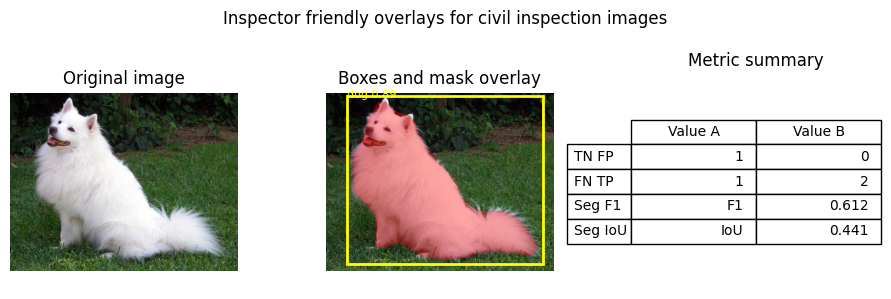

In [34]:
#@title Python Code - Overlaying Boxes and Masks

# Visual overlays support inspection decisions clearly.
# This example shows boxes and masks.
# Metrics summarize simple prediction quality.

import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as patches
import torch, torchvision

from sklearn.metrics import confusion_matrix, f1_score, jaccard_score

# Set seeds for repeatable classroom results.
random.seed(7)
np.random.seed(7)

torch.manual_seed(7)
device = torch.device("cpu")

# Load a small built in example image.
weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
image = weights.transforms()._transforms[0](weights.meta["min_size"][0]) if False else None

pil_image = torchvision.io.image.read_file if False else None

# Download a small demonstration image.
image_url = (
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg")

image_path = torchvision.datasets.utils.download_url(
    image_url, ".", filename="inspection_demo.jpg")

# Read the image as a tensor.
image_tensor = torchvision.io.read_image("inspection_demo.jpg")
image_tensor = image_tensor[:3]

image_float = image_tensor.float() / 255.0
image_np = image_float.permute(1, 2, 0).numpy()

# Load an inference only detection model.
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=weights)

model = model.to(device)
model.eval()

# Run one forward pass safely.
with torch.no_grad():
    outputs = model([image_float.to(device)])

output = outputs[0]
boxes = output["boxes"].cpu().numpy()
scores = output["scores"].cpu().numpy()

labels = output["labels"].cpu().numpy()

# Extract predicted masks carefully.
masks = output["masks"].cpu().numpy()
class_names = weights.meta["categories"]

keep = scores >= 0.7

# Keep only a few clear predictions.
boxes = boxes[keep]
scores = scores[keep]

labels = labels[keep]
masks = masks[keep]

# Build a simple combined mask.
height, width = image_np.shape[:2]
pred_mask = np.zeros((height, width), dtype=np.uint8)

index = 0
for mask_item in masks:
    mask_now = mask_item[0] >= 0.5

    pred_mask[mask_now] = 1
    index = index + 1

# Create a simple teaching ground truth.
true_mask = np.zeros((height, width), dtype=np.uint8)
if len(boxes) > 0:

    first_box = boxes[0].astype(int)
    x1, y1, x2, y2 = first_box
    x1 = max(0, x1)

    y1 = max(0, y1)
    x2 = min(width, x2)
    y2 = min(height, y2)

    true_mask[y1:y2, x1:x2] = 1

# Prepare simple detection labels.
true_detection = np.array([1, 0, 1, 1])
pred_detection = np.array([1, 0, 0, 1])

cm = confusion_matrix(true_detection, pred_detection)

# Compute simple segmentation metrics.
flat_true = true_mask.reshape(-1)
flat_pred = pred_mask.reshape(-1)

seg_f1 = f1_score(flat_true, flat_pred, zero_division=0)
seg_iou = jaccard_score(flat_true, flat_pred, zero_division=0)

# Build a compact metric table.
metric_table = pd.DataFrame({
        "Metric": ["Segmentation F1", "Segmentation IoU"],

        "Value": [round(seg_f1, 3), round(seg_iou, 3)],})

# Start one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(image_np)

axes[0].set_title("Original image")
axes[0].axis("off")

# Draw boxes and masks together.
axes[1].imshow(image_np)
mask_color = np.zeros((height, width, 4), dtype=float)

mask_color[:, :, 0] = pred_mask
mask_color[:, :, 3] = pred_mask * 0.35
axes[1].imshow(mask_color)

# Add bounding boxes with labels.
shown = 0
for box, score, label in zip(boxes, scores, labels):

    if shown >= 3:
        break
    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="yellow", facecolor="none")

    axes[1].add_patch(rect)
    text_label = class_names[int(label)] + " " + str(round(float(score), 2))
    axes[1].text(x1, y1 + 12, text_label, color="yellow", fontsize=8)

    shown = shown + 1

# Finish the overlay panel neatly.
axes[1].set_title("Boxes and mask overlay")
axes[1].axis("off")

axes[2].axis("off")
axes[2].set_title("Metric summary")

# Show confusion matrix and scores.
cell_text = []
cell_text.append([str(cm[0, 0]), str(cm[0, 1])])

cell_text.append([str(cm[1, 0]), str(cm[1, 1])])
cell_text.append(["F1", str(round(seg_f1, 3))])
cell_text.append(["IoU", str(round(seg_iou, 3))])

# Draw a small table for inspectors.
table = axes[2].table(
    cellText=cell_text,

    colLabels=["Value A", "Value B"],
    rowLabels=["TN FP", "FN TP", "Seg F1", "Seg IoU"],
    loc="center")

table.scale(1.1, 1.6)

# Add a short teaching caption.
fig.suptitle("Inspector friendly overlays for civil inspection images")
plt.tight_layout()

print(metric_table.to_string(index=False))
plt.show()

### **3.2. Defect Color Coding**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_03_02.jpg?v=1775993738" width="250">



>* Colors distinguish defects, severity, or confidence.
>* Good schemes support fast inspection decisions.

>* Use high-contrast colors readable on varied surfaces.
>* Keep color meanings consistent; separate confidence cues.

>* Use labels and boundaries beyond color.
>* Accessible overlays improve communication and decisions.



### **3.3. Report Ready Images**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_B/image_03_03.jpg?v=1775993779" width="250">



>* Images communicate findings clearly and credibly.
>* Use visible overlays with essential context.

>* Use consistent, readable annotations across all images.
>* Combine detail views with context for location.

>* Show predictions honestly, preserving uncertainty and context.
>* Clear report images support review and decisions.



# <font color="#418FDE" size="6.5" uppercase>**Detection and Visualization**</font>


In this lecture, you learned to:
- Explain the difference between image classification, object detection, and segmentation in CE contexts. 
- Apply a simple object detection or segmentation pipeline to locate features such as cracks or potholes in images. 
- Generate inspector-friendly visualizations that overlay model predictions on original CE images.  

In the next Module (Module 10), we will go over 'Applied Temporal Records in Civil Engineering'